In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’

In [4]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "12.5.+featureCounts$", full.names = T)

f_files

[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts"
 [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts"
 [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts"
 [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts"        
 [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts"        
 [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts"        
 [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts"      
 [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts"      
 [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts"      
[10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.1.featureCounts"    
[11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.2.featureCounts"    
[12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.3.featureCounts"    
[13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.1.featureCounts"    
[14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.2.featureCounts"    
[15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-12.5dpp.3.featureCounts"    
[16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.1.featureCounts"  
[17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.2.featureCounts"  
[18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-12.5dpp.3.featureCounts"  
[19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.1.featureCounts"   
[20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.2.featureCounts"   
[21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-12.5dpp.3.featureCounts"   
[22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.1.featureCounts"      
[23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.2.featureCounts"      
[24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-12.5dpp.3.featureCounts"      
[25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.1.featureCounts"     
[26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.2.featureCounts"     
[27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-12.5dpp.3.featureCounts"     
[28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.1.featureCounts"     
[29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.2.featureCounts"     
[30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-12.5dpp.3.f

In [5]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
 [4] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [7] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
[10] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
[13] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
[16] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
[19] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
[22] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
[25] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
[28] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
[31] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[34] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[37] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[40] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"

In [6]:
samplenames <- c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','A_J-P12.5','A_J-P12.5','A_J-P12.5','AKR_J-P12.5',
'AKR_J-P12.5','AKR_J-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CBA_J-P12.5',
'CBA_J-P12.5','CBA_J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5')

In [7]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
 [4] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [7] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
[10] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
[13] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
[16] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
[19] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
[22] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
[25] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
[28] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
[31] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[34] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[37] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[40] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"

In [8]:
lables <- c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3','A_J-P12.5.1',
'A_J-P12.5.2','A_J-P12.5.3','AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3','BALB_cJ-P12.5.1',
'BALB_cJ-P12.5.2','BALB_cJ-P12.5.3','C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3','C57BL_6NJ-P12.5.1',
'C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3','CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3','CBA_J-P12.5.1',
'CBA_J-P12.5.2','CBA_J-P12.5.3','DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3','FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3',
'NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3',
'PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3','SPRET_EiJ-P12.5.1',
'SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3','WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3')

In [9]:
#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames_order = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5')

In [10]:
#list of sample names with replicates 
#lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))
lables_order = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3',
'BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3',
'A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3',
'FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3',
'C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3',
'129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3',
'DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3',
'AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3',
'CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3',
'NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3',
'WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3',
'CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3',
'PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3',
'SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3')

In [11]:
raw <- readDGE(f_files, columns = c(1, 7), comment.char = "#", sep="\t", group= samplenames, labels = lables,)

In [12]:
rawdata <- raw


In [13]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/129S1_SvImJ_v3.2.gff3") #import gff3 file 
A129S1_SvImJ_geneName = na.omit(mcols(A129S1_SvImJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/A_J_v3.2.gff3") #import gff3 file 
A_J_geneName = na.omit(mcols(A_J )[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
AKR_J_geneName = na.omit(mcols(AKR_J)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/BALB_cJ_v3.2.gff3") #import gff3 file 
BALB_cJ_geneName = na.omit(mcols(BALB_cJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C3H_HeJ_v3.2.gff3") #import gff3 file 
C3H_HeJ_geneName = na.omit(mcols(C3H_HeJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C57BL_6NJ_v3.2.gff3") #import gff3 file 
C57BL_6NJ_geneName = na.omit(mcols(C57BL_6NJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CAST_EiJ_v3.2.gff3") #import gff3 file 
CAST_EiJ_geneName = na.omit(mcols(CAST_EiJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CBA_J_v3.2.gff3") #import gff3 file 
CBA_J_geneName = na.omit(mcols(CBA_J)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/DBA_2J_v3.2.gff3") #import gff3 file 
DBA_2J_geneName = na.omit(mcols(DBA_2J)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/FVB_NJ_v3.2.gff3") #import gff3 file 
FVB_NJ_geneName = na.omit(mcols(FVB_NJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NOD_ShiLtJ_v3.2.gff3") #import gff3 file 
NOD_ShiLtJ_geneName = na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 


PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/PWK_PhJ_v3.2.gff3") #import gff3 file 
PWK_PhJ_geneName = na.omit(mcols(PWK_PhJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/SPRET_EiJ_v3.2.gff3") #import gff3 file 
SPRET_EiJ_geneName = na.omit(mcols(SPRET_EiJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 


WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/WSB_EiJ_v3.2.gff3") #import gff3 file 
WSB_EiJ_geneName = na.omit(mcols(WSB_EiJ)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

In [14]:
geneName <- do.call("rbind", list(A129S1_SvImJ_geneName, A_J_geneName, AKR_J_geneName, BALB_cJ_geneName, C3H_HeJ_geneName, C57BL_6NJ_geneName, CAST_EiJ_geneName, CBA_J_geneName, DBA_2J_geneName , FVB_NJ_geneName,  NOD_ShiLtJ_geneName ,  PWK_PhJ_geneName, SPRET_EiJ_geneName,WSB_EiJ_geneName ))
geneName

DataFrame with 720152 rows and 2 columns
                  gene_id parent_gene_display_xref
              <character>              <character>
1      ENSMUSG00200053149                   Ugt1a1
2      ENSMUSG00200053174                  Gm20528
3      ENSMUSG00200032800            4933401J01Rik
4      ENSMUSG00200032799                  Gm26206
5      ENSMUSG00200032797                     Xkr4
...                   ...                      ...
720148 ENSMUSG00010031589                 BC022960
720149 ENSMUSG00010023776                  Gm15245
720150 ENSMUSG00010023781                     Mid1
720151 ENSMUSG00010023777                  Gm25651
720152 ENSMUSG00010023774            4933400A11Rik

In [15]:
rownames(geneName) <- geneName$gene_id
geneName$gene_id <- NULL
geneName

DataFrame with 720152 rows and 1 column
                   parent_gene_display_xref
                                <character>
ENSMUSG00200053149                   Ugt1a1
ENSMUSG00200053174                  Gm20528
ENSMUSG00200032800            4933401J01Rik
ENSMUSG00200032799                  Gm26206
ENSMUSG00200032797                     Xkr4
...                                     ...
ENSMUSG00010031589                 BC022960
ENSMUSG00010023776                  Gm15245
ENSMUSG00010023781                     Mid1
ENSMUSG00010023777                  Gm25651
ENSMUSG00010023774            4933400A11Rik

In [16]:
library(dplyr)
rawdata$counts <- merge(x=raw$counts, y=geneName,by = 0,all.x=TRUE ) #left merge 


In [17]:
rawdata_copy <- rawdata
rawdata_copy$counts['Row.names'] <- NULL #remove the columns name Row.names


In [18]:
rawdata_copy$counts <- rawdata_copy$counts[!is.na(rawdata_copy$counts$parent_gene_display_xref),] #remove NA 
rawdata_copy$counts

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,A_J-P12.5.1,A_J-P12.5.2,A_J-P12.5.3,AKR_J-P12.5.1,AKR_J-P12.5.2,AKR_J-P12.5.3,BALB_cJ-P12.5.1,⋯,PWK_PhJ-P12.5.1,PWK_PhJ-P12.5.2,PWK_PhJ-P12.5.3,SPRET_EiJ-P12.5.1,SPRET_EiJ-P12.5.2,SPRET_EiJ-P12.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,parent_gene_display_xref
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,225.83,251.68,253.94,0,0,0,Gm37340
10,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,1.00,1.00,2.00,0,0,0,Ptf1a
11,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,113.00,141.25,108.00,0,0,0,Msrb2
12,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,4.78,6.09,5.32,0,0,0,4921504E06Rik
13,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,5016.30,5626.05,5907.40,0,0,0,Upf2
14,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,676.25,671.82,703.00,0,0,0,Proser2
15,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,506.00,540.75,530.04,0,0,0,Dhtkd1
16,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,282.00,354.00,378.33,0,0,0,Echdc3
17,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,11.83,13.50,11.33,0,0,0,C1ql3


In [19]:

rawdata_copy$counts <- rawdata_copy$counts %>% 
  group_by(parent_gene_display_xref) %>% 
  summarise(across(everything(), sum))

#rawdata_copy$counts <- aggregate(. ~ parent_gene_display_xref, rawdata_copy, sum, na.rm = TRUE)

In [20]:

rawdata_copy$counts <- as.data.frame(rawdata_copy$counts[!duplicated(rawdata_copy$counts$parent_gene_display_xref), ])  #remove dulicate values 
rawdata_copy

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-P12.5,31878714,1
129S1_SvImJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-P12.5,31993372,1
129S1_SvImJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-P12.5,32262165,1
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts,A_J-P12.5,29667123,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts,A_J-P12.5,33838073,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts,A_J-P12.5,31691090,1
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,32170112,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,32999174,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,34885662,1


In [21]:
rownames(rawdata_copy$counts) <- rawdata_copy$counts$parent_gene_display_xref #set rawname to gene symbloes 
rawdata_copy

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-P12.5,31878714,1
129S1_SvImJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-P12.5,31993372,1
129S1_SvImJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-P12.5,32262165,1
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts,A_J-P12.5,29667123,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts,A_J-P12.5,33838073,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts,A_J-P12.5,31691090,1
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,32170112,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,32999174,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,34885662,1


In [22]:
rawdata_copy$counts$parent_gene_display_xref <- NULL #remove gene symbole columns 

In [23]:
rawdata_copy

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-P12.5,31878714,1
129S1_SvImJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-P12.5,31993372,1
129S1_SvImJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-P12.5,32262165,1
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts,A_J-P12.5,29667123,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts,A_J-P12.5,33838073,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts,A_J-P12.5,31691090,1
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,32170112,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,32999174,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,34885662,1


In [24]:
#DESeq and PCA and Dandogram 

#conda install -c bioconda bioconductor-deseq2 r-gplots r-rcolorbrewer r-ggplot2 r-tidyr r-ggrepel r-dplyr -y 
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 

In [25]:

#save results in this folder 
#mkdir -p  /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/AKR_J
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/P12.5")

In [26]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"

In [27]:
# Now we build a DESeq2 Count dataset and normalize it.
mircounts <- rawdata_copy$counts
# Reorder columns
mircounts = mircounts[lables_order]

cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

failed to open the port 11369, trying a new port...

estimating dispersions

gene-wise dispersion estimates: 124 workers

  Note: levels of factors in the design contain characters other than
  lette

In [28]:
#rlog normalisations
rl=vst(cds)
pdf("P12.5_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames)
postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames)
dev.off()

png 
  2

In [29]:
pdf("P12.5_InitialHeatMap.pdf",paper="special",width=17, height=17,title="E16,5",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="E16.5",cexRow=1,cexCol=1,
    margins=c(10,10),na.rm=T,key=T,offsetRow=0,offsetCol=0,keysize=0.3,density.info='histogram')
dev.off()

png 
  2

In [30]:


custom_colors <- c(
  'C57BL_6NJ-E16.5' = '#0000FF',    # Blue
  'C57BL_6NJ-P12.5' = '#00FF00',    # Green
  'C57BL_6NJ-P20.5' = '#FF0000',    # Red
  'BALB_cJ-E16.5' = '#800080',      # Purple
  'BALB_cJ-P12.5' = '#FFA500',      # Orange
  'BALB_cJ-P20.5' = '#FF00FF',      # Magenta
  'A_J-E16.5' = '#A52A2A',          # Brown
  'A_J-P12.5' = '#FFC0CB',          # Pink
  'A_J-P20.5' = '#A9A9A9',          # Dark Gray
  'FVB_NJ-E16.5' = '#ADD8E6',       # Light Blue
  'FVB_NJ-P12.5' = '#90EE90',       # Light Green
  'FVB_NJ-P20.5' = '#FFB6C1',       # Light Red
  'C3H_HeJ-E16.5' = '#9400D3',      # Dark Purple
  'C3H_HeJ-P12.5' = '#FF8C00',      # Dark Orange
  'C3H_HeJ-P20.5' = '#8A2BE2',      # Dark Magenta
  '129S1_SvImJ-E16.5' = '#9370DB',  # Light Purple
  '129S1_SvImJ-P12.5' = '#FFD700',  # Light Orange
  '129S1_SvImJ-P20.5' = '#FFFFE0',  # Light Yellow
  'DBA_2J-E16.5' = '#D2691E',       # Light Brown
  'DBA_2J-P12.5' = '#FF69B4',       # Light Pink
  'DBA_2J-P20.5' = '#A9A9A9',       # Dark Gray
  'AKR_J-E16.5' = '#ADD8E6',        # Light Blue
  'AKR_J-P12.5' = '#90EE90',        # Light Green
  'AKR_J-P20.5' = '#FFB6C1',        # Light Red
  'CBA_J-E16.5' = '#9400D3',        # Dark Purple
  'CBA_J-P12.5' = '#008B8B',        # Dark Cyan
  'CBA_J-P20.5' = '#8A2BE2',        # Dark Magenta
  'NOD_ShiLtJ-E16.5' = '#9370DB',   # Light Purple
  'NOD_ShiLtJ-P12.5' = '#FFD700',   # Light Orange
  'NOD_ShiLtJ-P20.5' = '#E0FFFF',   # Light Cyan
  'WSB_EiJ-E16.5' = '#EE82EE',      # Light Magenta
  'WSB_EiJ-P12.5' = '#FFFF00',      # Light Yellow
  'WSB_EiJ-P20.5' = '#8B4513',      # Dark Brown
  'CAST_EiJ-E16.5' = '#FF69B4',     # Light Pink
  'CAST_EiJ-P12.5' = '#A9A9A9',     # Dark Gray
  'CAST_EiJ-P20.5' = '#ADD8E6',     # Light Blue
  'PWK_PhJ-E16.5' = '#90EE90',      # Light Green
  'PWK_PhJ-P12.5' = '#FFB6C1',      # Light Red
  'PWK_PhJ-P20.5' = '#9400D3',      # Dark Purple
  'SPRET_EiJ-E16.5' = '#FF8C00',    # Dark Orange
  'SPRET_EiJ-P12.5' = '#008B8B',    # Dark Cyan
  'SPRET_EiJ-P20.5' = '#8A2BE2'     # Dark Magenta
)

# Check for color duplication and assign separate colors if needed
duplicated_colors <- duplicated(custom_colors) | duplicated(custom_colors, fromLast = TRUE)

# Get a vector of unique colors
available_colors <- c('#000000', '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', '#FF6600', '#6600CC', '#00FF00', '#FF00FF', '#FFFF00', '#00FFFF', '#FFCC00', '#00CC66', '#9933CC', '#996633', '#6699CC', '#006600', '#6600CC', '#990099', '#FF6666', '#CCFF66', '#996633', '#FF9933', '#FFFF00', '#FF00CC', '#FF9900', '#666633', '#FF00FF', '#FF00CC', '#FF6600', '#CC0000', '#00CC00', '#666666', '#990000', '#FF66CC', '#FFFF00', '#FF6600', '#9933CC', '#9900CC', '#FF00CC', '#00CC00', '#FF00CC', '#CC6600', '#66CC66', '#660000', '#CC0000', '#CC00FF', '#FFCC00', '#990066', '#00FF00', '#0066FF', '#FF66FF', '#33CC33', '#996600', '#FF00FF', '#9966FF', '#FFFF00', '#FF3300', '#00FFFF', '#666633', '#33CC33', '#FF6600', '#FF6600', '#FF00FF', '#CC9900')

# Assign unique colors to duplicated entries
custom_colors[duplicated_colors] <- available_colors[!duplicated_colors]


# Extract strain names
strain_names <- sub("-(E|P)[0-9\\.]+", "", names(custom_colors))

# Generate a unique set of strain names
unique_strain_names <- unique(strain_names)
unique_strain_names
# Define a set of bright colors from ggplot2 palette

bright_colors <- c(
  '#1F4788',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
  '#1B6F77',
  '#7E7E00'
)


# Create a color mapping for each unique strain name
color_mapping <- setNames(bright_colors, unique_strain_names)
color_mapping 
# Apply color mapping to the original custom_colors
reassigned_colors <- color_mapping[strain_names]

# Combine with the original labels to create the final color assignments
final_colors <- setNames(reassigned_colors, names(custom_colors))
final_colors

Warning message in custom_colors[duplicated_colors] <- available_colors[!duplicated_colors]:
“number of items to replace is not a multiple of replacement length”


[1] "C57BL_6NJ"   "BALB_cJ"     "A_J"         "FVB_NJ"      "C3H_HeJ"    
 [6] "129S1_SvImJ" "DBA_2J"      "AKR_J"       "CBA_J"       "NOD_ShiLtJ" 
[11] "WSB_EiJ"     "CAST_EiJ"    "PWK_PhJ"     "SPRET_EiJ"

C57BL_6NJ     BALB_cJ         A_J      FVB_NJ     C3H_HeJ 129S1_SvImJ 
  "#1F4788"   "#003300"   "#B80000"   "#6E2162"   "#D46A00"   "#880088" 
     DBA_2J       AKR_J       CBA_J  NOD_ShiLtJ     WSB_EiJ    CAST_EiJ 
  "#AC9600"   "#7D3C1D"   "#A63A50"   "#3E5B2B"   "#235F92"   "#00662D" 
    PWK_PhJ   SPRET_EiJ        <NA>        <NA> 
  "#CF5E75"   "#A29ACD"   "#1B6F77"   "#7E7E00"

C57BL_6NJ-E16.5   C57BL_6NJ-P12.5   C57BL_6NJ-P20.5     BALB_cJ-E16.5 
        "#1F4788"         "#1F4788"         "#1F4788"         "#003300" 
    BALB_cJ-P12.5     BALB_cJ-P20.5         A_J-E16.5         A_J-P12.5 
        "#003300"         "#003300"         "#B80000"         "#B80000" 
        A_J-P20.5      FVB_NJ-E16.5      FVB_NJ-P12.5      FVB_NJ-P20.5 
        "#B80000"         "#6E2162"         "#6E2162"         "#6E2162" 
    C3H_HeJ-E16.5     C3H_HeJ-P12.5     C3H_HeJ-P20.5 129S1_SvImJ-E16.5 
        "#D46A00"         "#D46A00"         "#D46A00"         "#880088" 
129S1_SvImJ-P12.5 129S1_SvImJ-P20.5      DBA_2J-E16.5      DBA_2J-P12.5 
        "#880088"         "#880088"         "#AC9600"         "#AC9600" 
     DBA_2J-P20.5       AKR_J-E16.5       AKR_J-P12.5       AKR_J-P20.5 
        "#AC9600"         "#7D3C1D"         "#7D3C1D"         "#7D3C1D" 
      CBA_J-E16.5       CBA_J-P12.5       CBA_J-P20.5  NOD_ShiLtJ-E16.5 
        "#A63A50"         "#A63A50"         "#A63A50"         "#3E5B2B" 
 NOD_ShiLtJ-P12.5  NOD_ShiLtJ-P20.5     WSB_EiJ-E16.5     WSB_EiJ-P12.5 
        "#3E5B2B"         "#3E5B2B"         "#235F92"         "#235F92" 
    WSB_EiJ-P20.5    CAST_EiJ-E16.5    CAST_EiJ-P12.5    CAST_EiJ-P20.5 
        "#235F92"         "#00662D"         "#00662D"         "#00662D" 
    PWK_PhJ-E16.5     PWK_PhJ-P12.5     PWK_PhJ-P20.5   SPRET_EiJ-E16.5 
        "#CF5E75"         "#CF5E75"         "#CF5E75"         "#A29ACD" 
  SPRET_EiJ-P12.5   SPRET_EiJ-P20.5 
        "#A29ACD"         "#A29ACD"

In [31]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 20000, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], Samples = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "Samples", label = "name")) + geom_point(size = 2) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed()+ 
    theme(legend.text=element_text(size=5),panel.background = element_rect(fill = "white")) + ggtitle(timePoint) + scale_color_manual(values = final_colors ) +  guides(color = guide_legend(title = "Strains"))
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("P12.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("P12.5_PCA_After_1vs3_Beginning_500_",timePoint,".pdf"),,paper="a4")
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = 500))
dev.off()
}


[1] "P12.5"


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


In [32]:

##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 20000, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], Samples = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "Samples", label = "name")) + geom_point(size = 2) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + 
    theme(legend.text=element_text(size=5),panel.background = element_rect(fill = "white")) + ggtitle(timePoint) + scale_color_manual(values = final_colors ) +  guides(color = guide_legend(title = "Strains"))
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("P12.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("P12.5_PCA_After_1vs3_Beginning_500_",timePoint,".pdf"),paper="a4")
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = 500))
dev.off()
}

[1] "P12.5"


In [33]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 20000, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], Samples = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "Samples", label = "name")) + geom_point(size = 2) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + 
    ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) +
     theme(legend.text=element_text(size=5),panel.background = element_rect(fill = "white")) + ggtitle(timePoint) + scale_color_manual(values = final_colors ) +  guides(color = guide_legend(title = "Strains"))
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("P12.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("P12.5_PCA_After_2vs3_Beginning_all_genes",timePoint,".pdf"),paper="a4")
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}

[1] "P12.5"


In [34]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 20000, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], Samples = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "Samples", label = "name")) + geom_point(size = 2) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + 
     theme(legend.text=element_text(size=5),panel.background = element_rect(fill = "white")) + ggtitle(timePoint) + scale_color_manual(values = final_colors ) +  guides(color = guide_legend(title = "Strains"))
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("P12.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
#pdf(paste0("E16.5_PCA_After_2vs3_Beginning_500_",timePoint,".pdf"))
pdf(paste0("P12.5_PCA_After_1vs2_Beginning_all_genes",timePoint,".pdf"),paper="a4")
print(plotPCA.san(rl.sub, intgroup = "sample", ntop =nrow(counts(cds))))
dev.off()
}

[1] "P12.5"


In [35]:
eigenvalue_indices <- 1:10

rv <- rowVars(assay(rl))
select <- order(rv, decreasing = TRUE)[seq_len(min(ntop = nrow(counts(cds)), length(rv)))]
pca <- prcomp(t(assay(rl)[select, ]))

# Calculate the variance explained by each eigenvalue
variance_explained <- pca$sdev^2 / sum(pca$sdev^2)

# Create a data frame for plotting
eigenvalue_data <- data.frame(
  Index = eigenvalue_indices,
  VarianceExplained = round(variance_explained[eigenvalue_indices] * 100),
  LabelPosition = variance_explained[eigenvalue_indices] * 50  # Position at the middle of each bar
)

# Create the barplot using ggplot
bar_plot <- ggplot(data = eigenvalue_data, aes(x = Index, y = VarianceExplained)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(
    title = "First 10 Principal Components",
    x = "Eigenvalue Index",
    y = "Variance Explained (%)"
  ) +
  scale_x_continuous(breaks = eigenvalue_indices, labels = eigenvalue_indices) +
  scale_y_continuous(limits = c(0, max(eigenvalue_data$VarianceExplained) * 1.1)) +
  geom_text(aes(label = round(VarianceExplained, 2)), y = max(eigenvalue_data$VarianceExplained) * 0.5,angle = 90) + 
  #geom_text(aes(label = round(VarianceExplained, 2)), vjust = -0.5, angle = 90) +  # Label position and rotation
  theme_minimal() + theme(plot.background = element_rect(fill = "white"))

# Save the plot to a PDF file
pdf("P12.5_eigenvariance_barplot_all_genes.pdf", width = 3, height = 4)
print(bar_plot)
dev.off()

png 
  2

In [36]:
rv <- rowVars(assay(rl))
select <- order(rv, decreasing = TRUE)[seq_len(min(ntop = 500, length(rv)))]
pca <- prcomp(t(assay(rl)[select, ]))

# Calculate the variance explained by each eigenvalue
variance_explained <- pca$sdev^2 / sum(pca$sdev^2)

# Create a data frame for plotting
eigenvalue_data <- data.frame(
  Index = eigenvalue_indices,
  VarianceExplained = round(variance_explained[eigenvalue_indices] * 100),
  LabelPosition = variance_explained[eigenvalue_indices] * 50  # Position at the middle of each bar
)

# Create the barplot using ggplot
bar_plot <- ggplot(data = eigenvalue_data, aes(x = Index, y = VarianceExplained)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(
    title = "First 10 Principal Components",
    x = "Eigenvalue Index",
    y = "Variance Explained (%)"
  ) +
  scale_x_continuous(breaks = eigenvalue_indices, labels = eigenvalue_indices) +
  scale_y_continuous(limits = c(0, max(eigenvalue_data$VarianceExplained) * 1.1)) +
  geom_text(aes(label = round(VarianceExplained, 2)), y = max(eigenvalue_data$VarianceExplained) * 0.5,angle = 90) + 
  #geom_text(aes(label = round(VarianceExplained, 2)), vjust = -0.5, angle = 90) +  # Label position and rotation
  theme_minimal() + theme(plot.background = element_rect(fill = "white"))

# Save the plot to a PDF file
pdf("P12.5_eigenvariance_barplot_500.pdf", width = 3, height = 4)
print(bar_plot)
dev.off()

png 
  2

In [37]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="P12.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

In [38]:
# Load necessary packages
library(EnhancedVolcano)
library(clusterProfiler)
library(DESeq2)
library(doParallel)
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Load required libraries
library(foreach)
library(doParallel)
library(EnhancedVolcano)  # Make sure you have this package installed

# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}

# Set up parallel processing
num_cores <- 50  # Set the number of CPU cores to use
registerDoParallel(cores = num_cores)

# Define a function for generating a volcano plot
generate_volcano_plot <- function(contrast, cds) {
    col1 <- contrast[2]
    col2 <- contrast[3]
    
    res <- results(cds, contrast = contrast)

    volcano_plot <- EnhancedVolcano(res,
                                        lab = rownames(res),
                                        x = 'log2FoldChange',
                                        y = 'pvalue',
                                        title = paste(col1, "vs", col2, "Volcano Plot"),
                                        pCutoff = 0.05,
                                        FCcutoff = 2,
                                        col=  c('green', 'black', 'blue', 'red3'),
                                        colAlpha = 1,    cutoffLineType = 'blank',
                                        cutoffLineCol = 'black',
                                        cutoffLineWidth = 0.8,
                                        hline = c(10e-12, 10e-36, 10e-60, 10e-84),
                                        hlineCol = c('grey0', 'grey25','grey50','grey75'),
                                        hlineType = 'longdash',
                                        hlineWidth = 0.8,
                                        gridlines.major = FALSE,
                                        gridlines.minor = FALSE,
                                        xlim = c(-10, 10))
    # Add text labels for upregulated, downregulated, and nonsignificant genes            
    
            
    
    plot_filename <- paste("volcano_plots/", col1, "_vs_", col2, "_volcano_plot.png", sep = "")
    png(plot_filename, width = 1000, height = 1200)
    print(volcano_plot)
    dev.off()

}


# Run volcano plots in parallel for each contrast
foreach(contrast = contrast_list, .packages = c("EnhancedVolcano")) %dopar% {
    generate_volcano_plot(contrast, cds)
}

# Stop parallel processing
stopImplicitCluster()



clusterProfiler v4.8.1  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:lattice’:

    dotplot


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Loading required package: foreach


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel



[[1]]
png 
  2 

[[2]]
png 
  2 

[[3]]
png 
  2 

[[4]]
png 
  2 

[[5]]
png 
  2 

[[6]]
png 
  2 

[[7]]
png 
  2 

[[8]]
png 
  2 

[[9]]
png 
  2 

[[10]]
png 
  2 

[[11]]
png 
  2 

[[12]]
png 
  2 

[[13]]
png 
  2 

[[14]]
png 
  2 

[[15]]
png 
  2 

[[16]]
png 
  2 

[[17]]
png 
  2

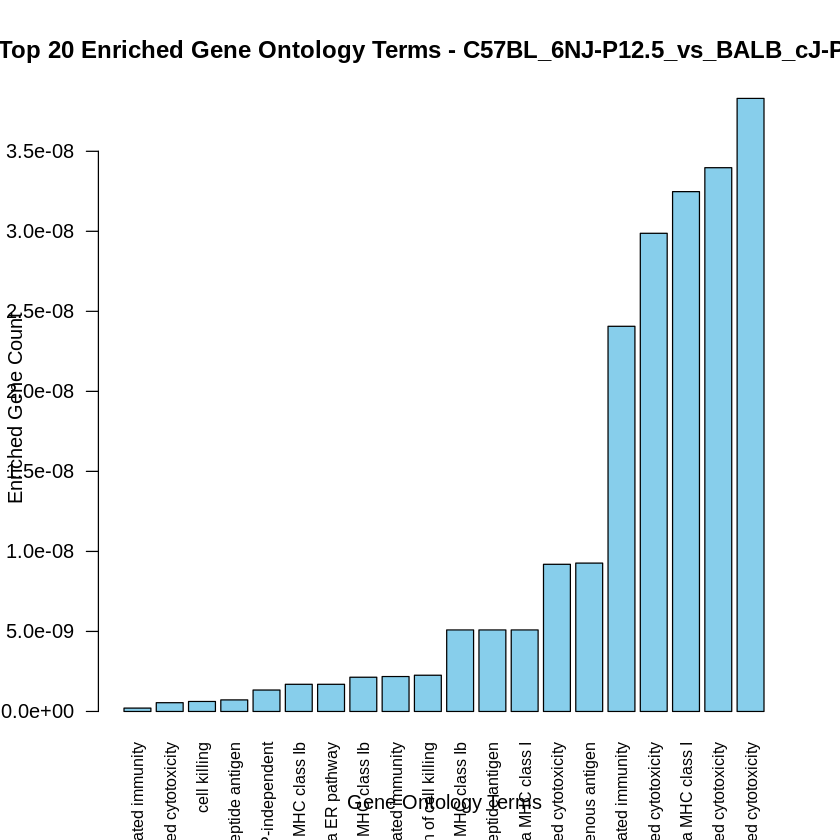

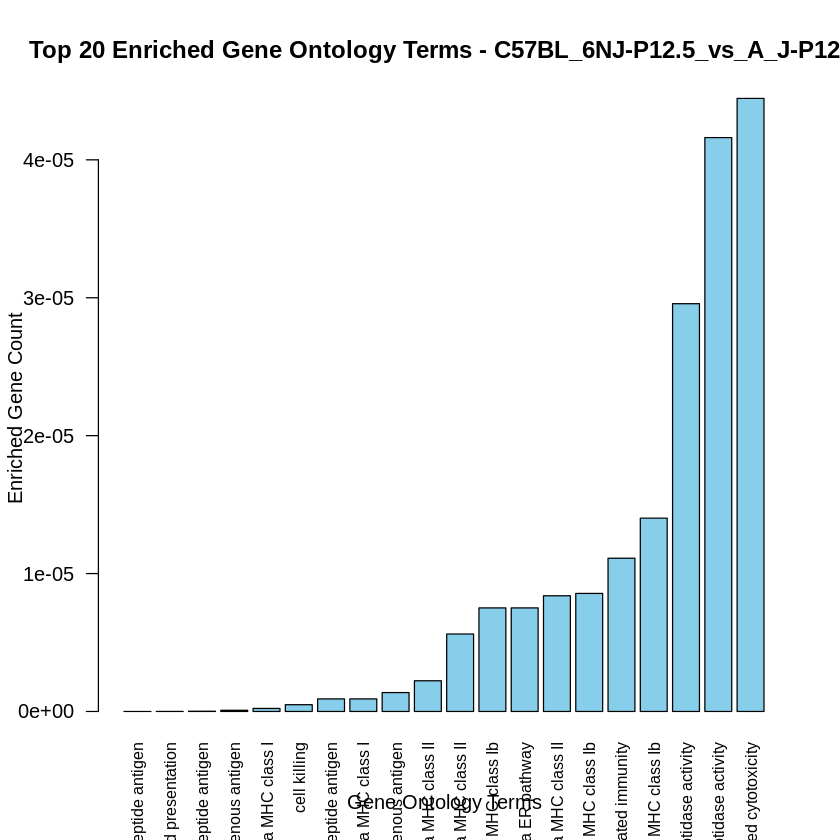

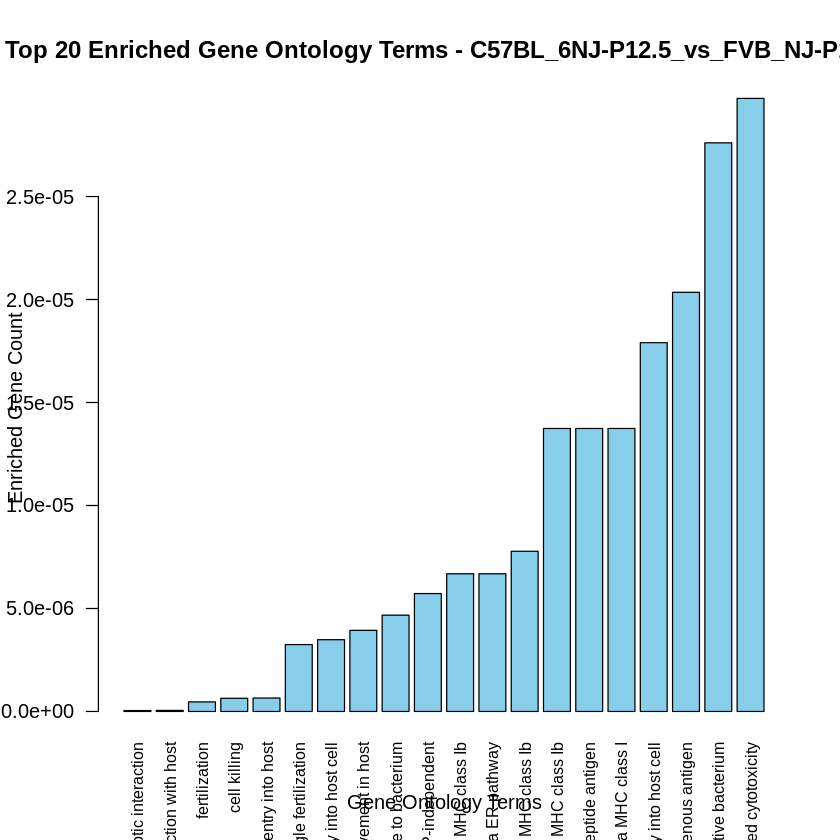

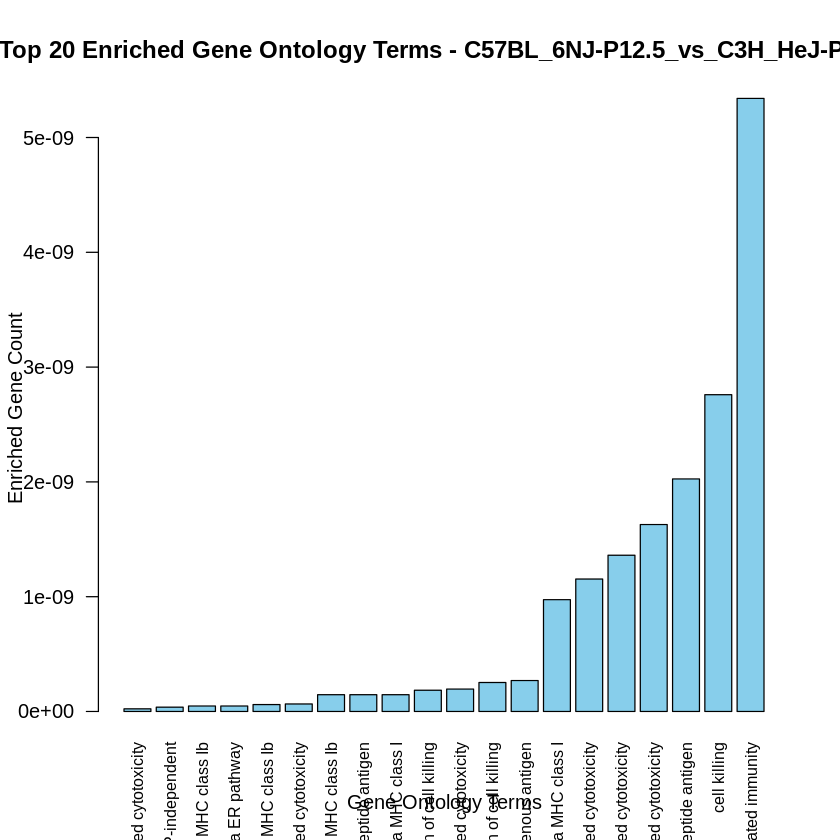

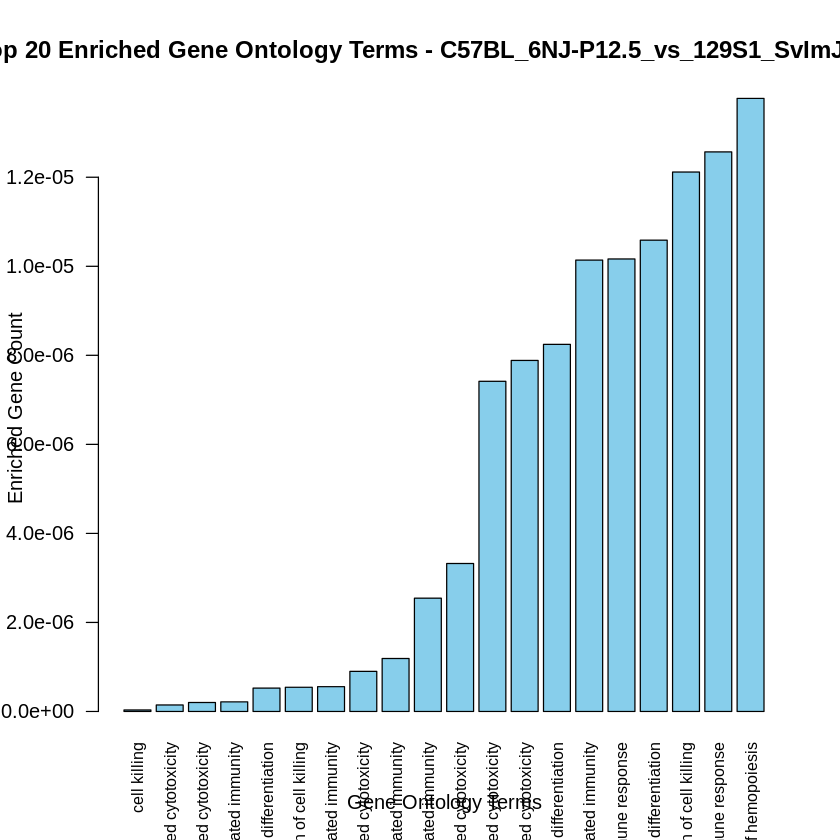

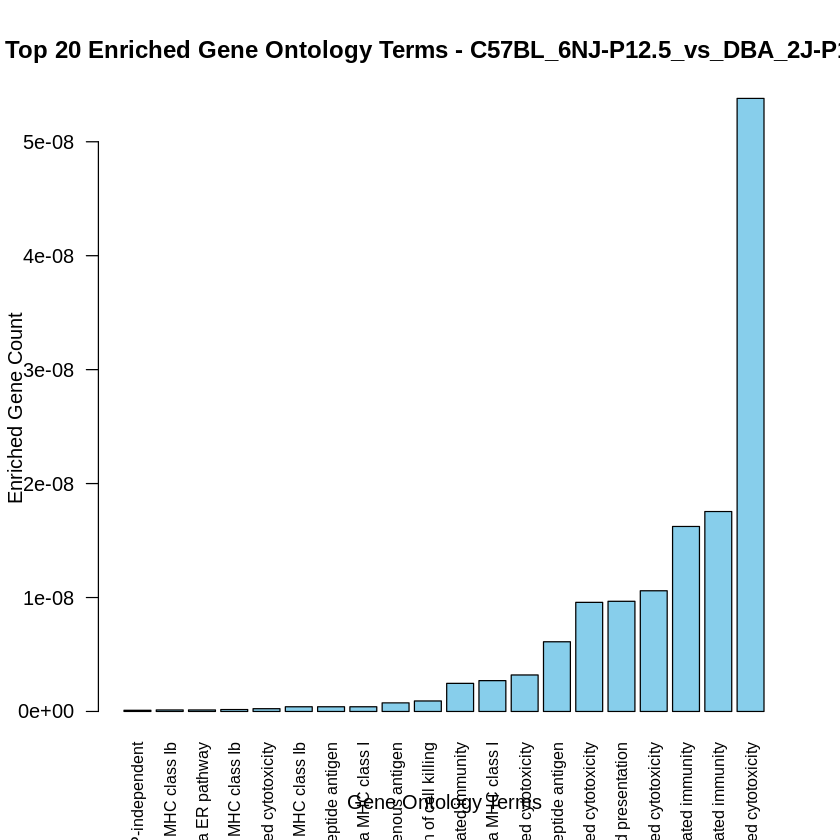

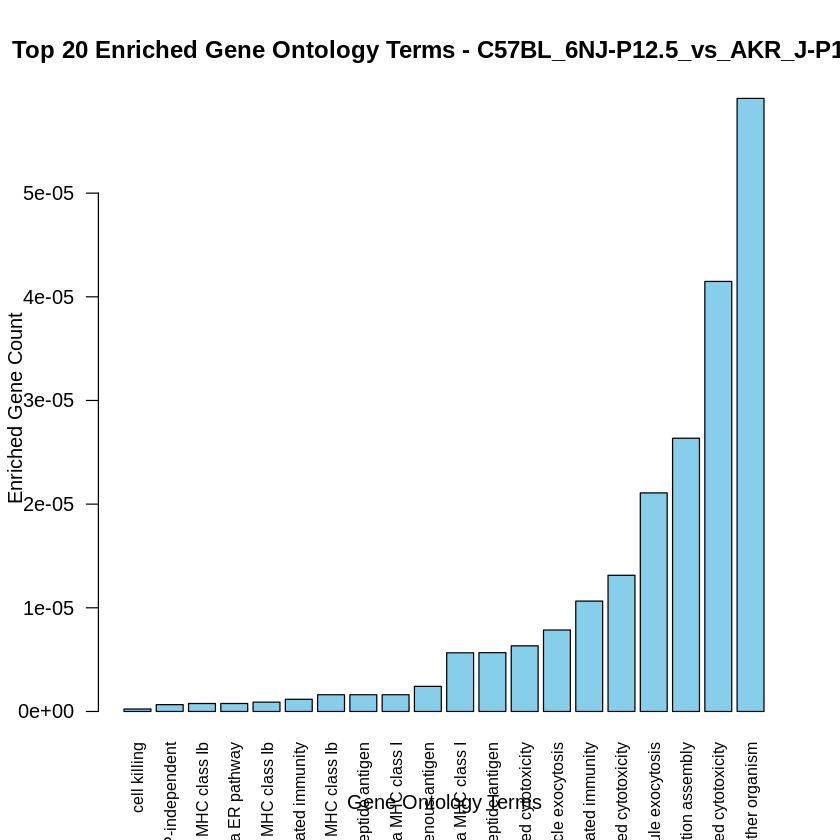

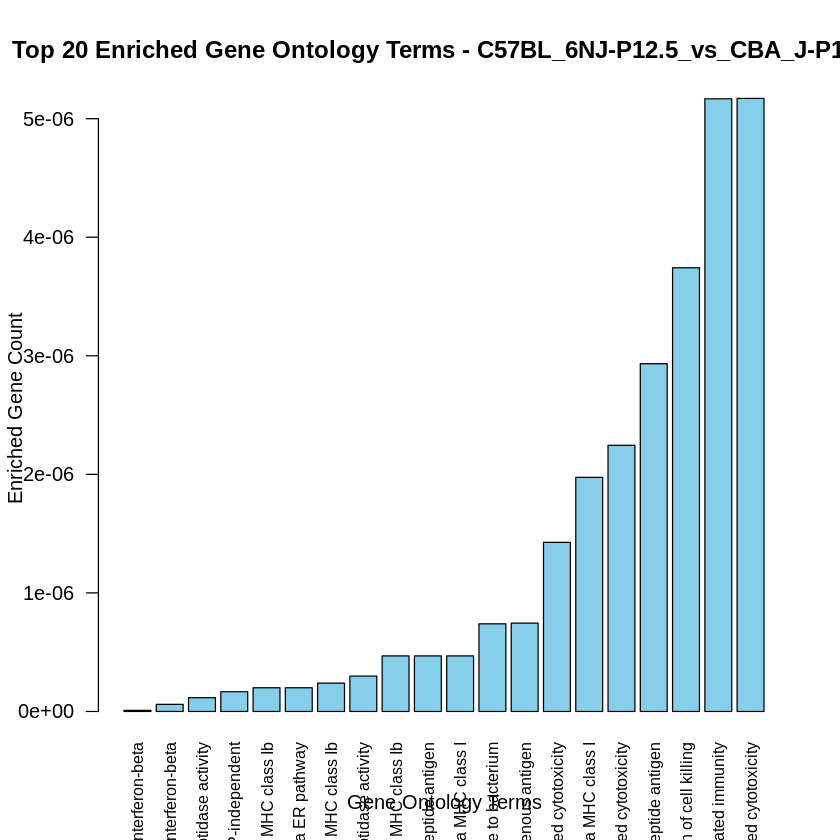

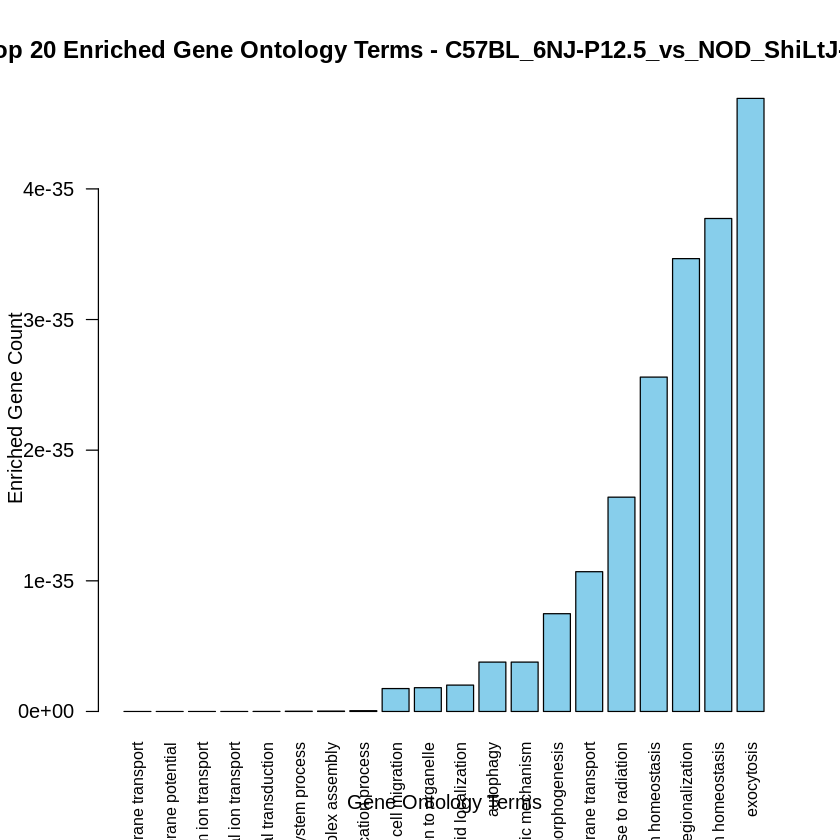

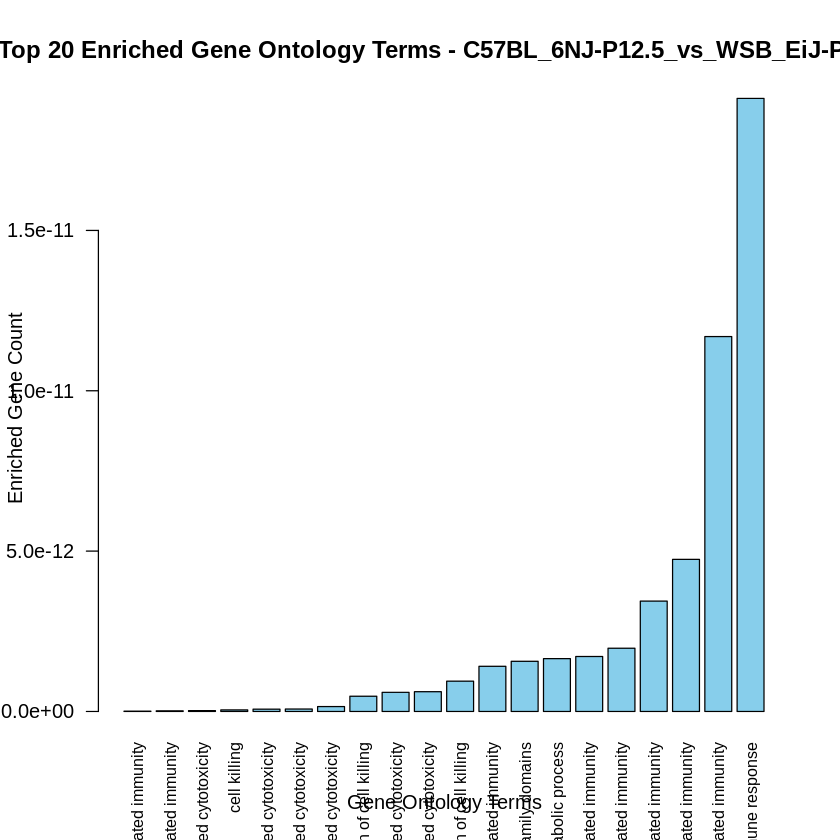

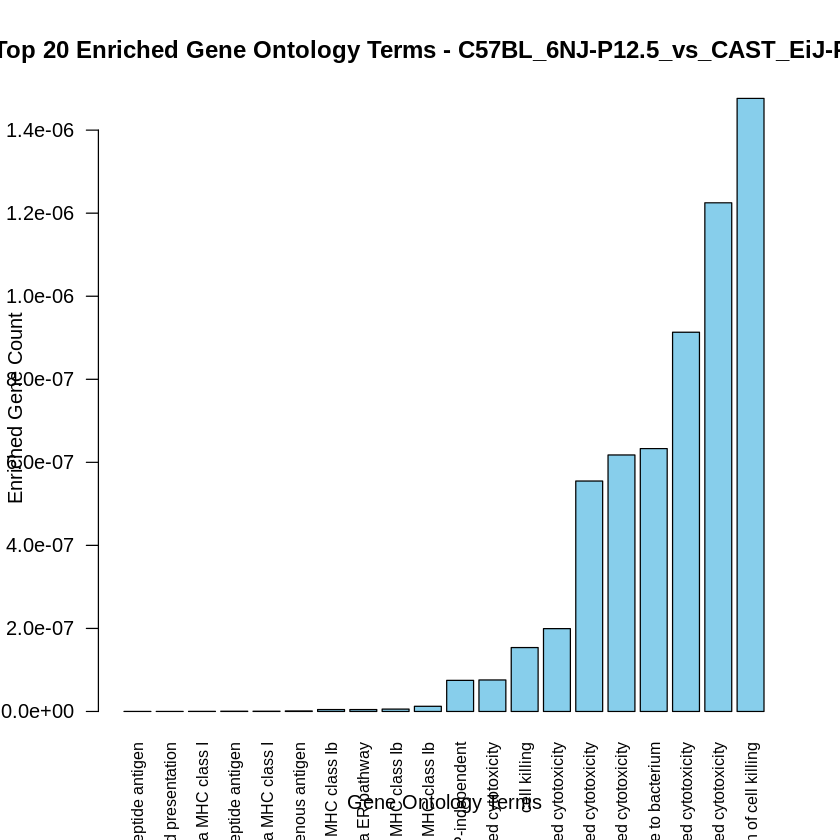

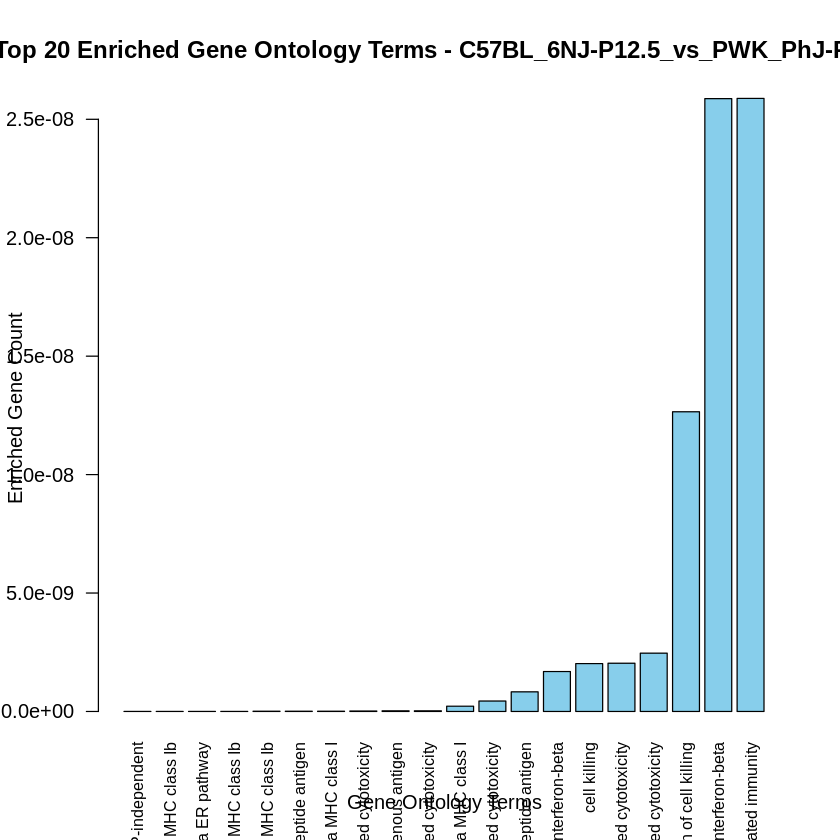

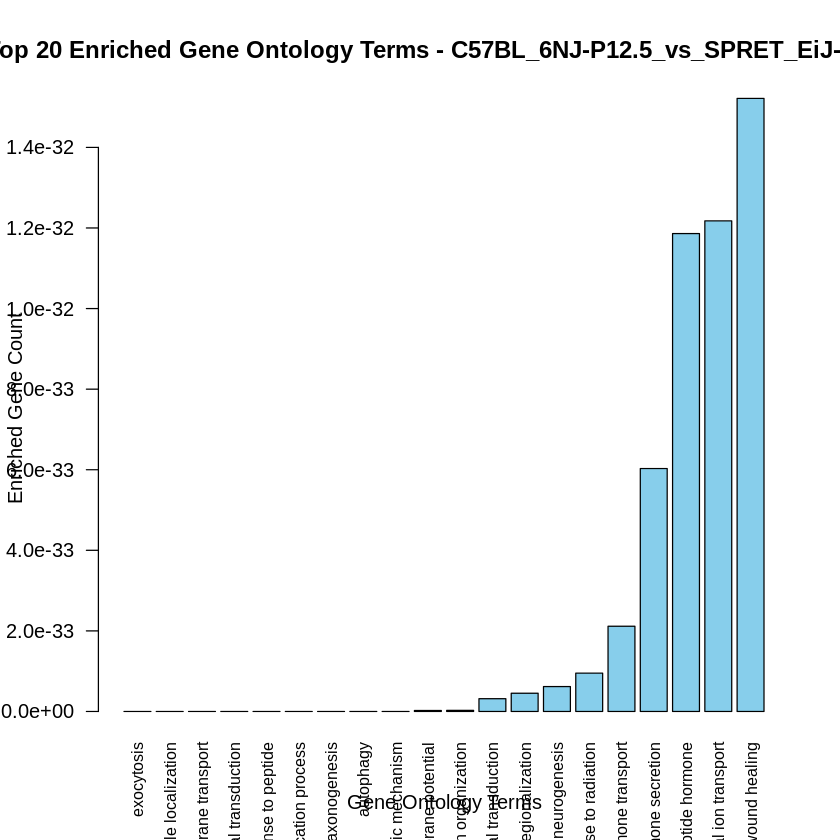

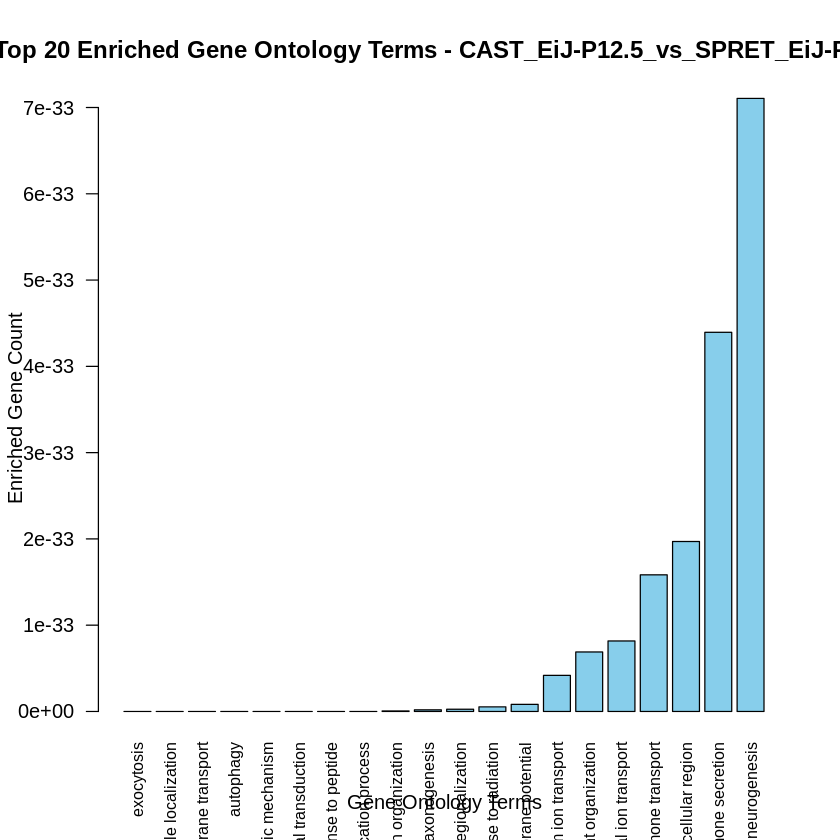

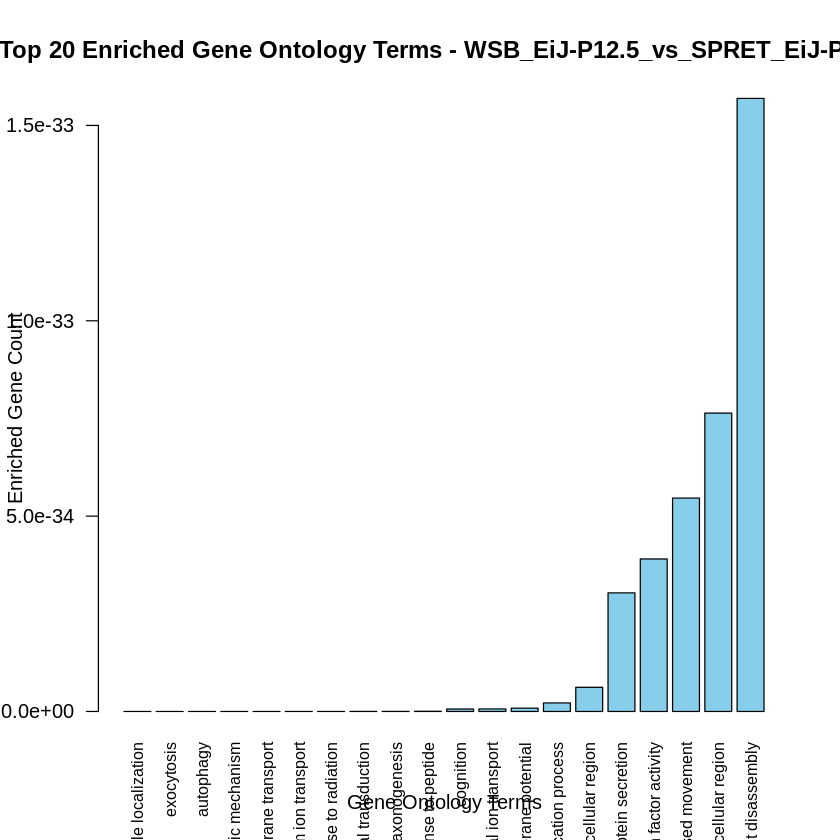

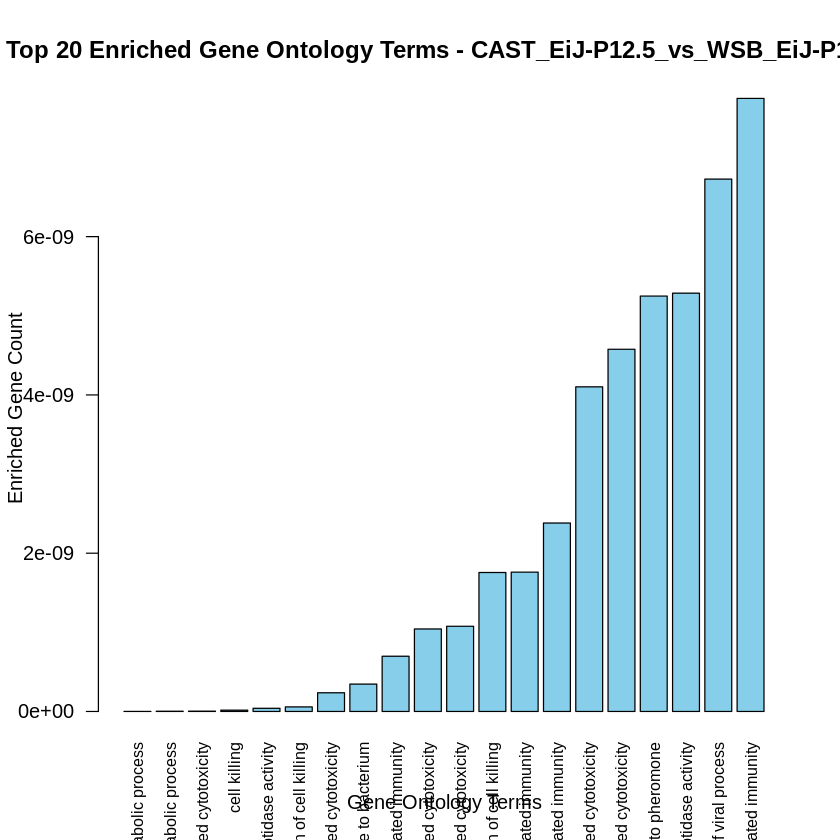

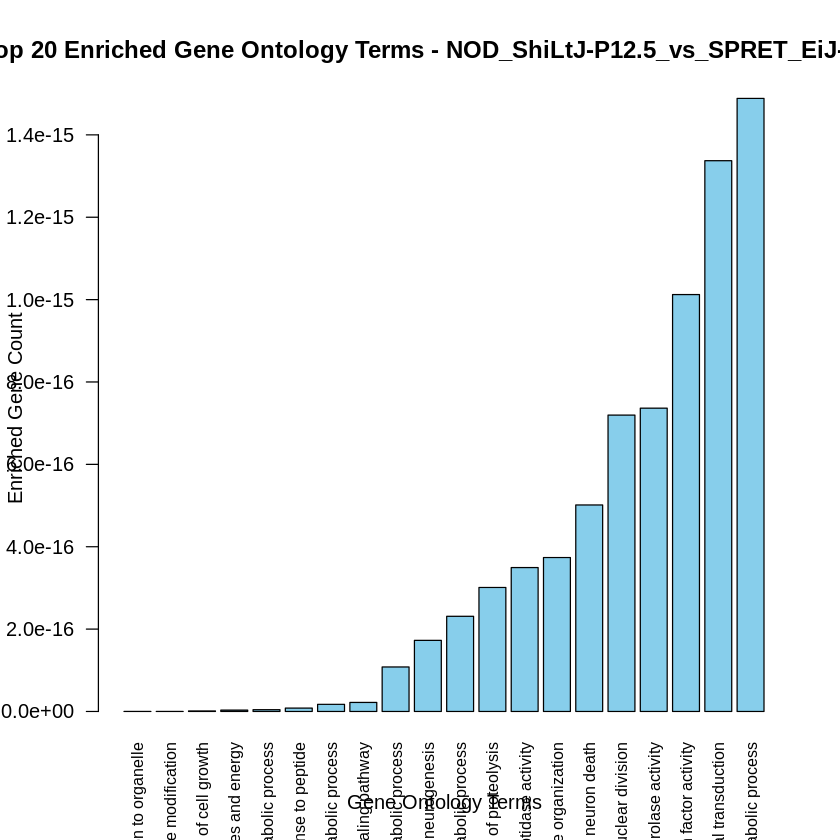

In [39]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Create a directory if it doesn't exist
if (!file.exists("gene_ontology_plots")) {
  dir.create("gene_ontology_plots")
}


for (i in seq_along(contrast_list)) {
  contrast_name <- paste(contrast_list[[i]][-1], collapse = "_vs_")
  
  # Get the current GO enrichment results
  go_enrichment <- go_enrichment_list[[i]]
  
  # Filter out rows with no enriched terms
  enriched_terms <- go_enrichment[go_enrichment$Count > 0, ]
  
  # Sort the enriched terms by p-value and keep the top 20
  top_enriched_terms <- enriched_terms[order(enriched_terms$pvalue), ][1:20, ]
  
  # Create a bar plot for the top enriched terms
  barplot(top_enriched_terms$pvalue, names.arg = top_enriched_terms$Description,
          main = paste("Top 20 Enriched Gene Ontology Terms -", contrast_name),
          xlab = "Gene Ontology Terms", ylab = "Enriched Gene Count",
          las = 2, cex.names = 0.8, col = "skyblue", border = "black")
  
  # Save the plot to the directory
  plot_filename <- paste("gene_ontology_plots", contrast_name, "top_20_barplot.png", sep = "_")
  dev.copy(png, filename = plot_filename)
  dev.off()
}








In [ ]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 20000, returnData = FALSE, plotLoadings = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]), scale. = TRUE)
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], Samples = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  p <- ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "Samples", label = "name")) + geom_point(size = 2) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + 
    ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) +
     theme(legend.text=element_text(size=5),panel.background = element_rect(fill = "white")) + ggtitle(timePoint) + scale_color_manual(values = final_colors ) +  guides(color = guide_legend(title = "Strains"))
  
  if (plotLoadings) {
    loading_scores <- pca$rotation
    print(loading_scores)
    #p <- p + geom_segment(aes(x = 0, y = 0, xend = PC2 * 2, yend = PC3 * 2),
                           #data = loading_scores, color = "blue")
  }

}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("P12.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("P20.5_PCA_After_2vs3_loading_500_",timePoint,".pdf"),paper="a4")
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = 500, plotLoadings = TRUE))
dev.off()
}

In [40]:

# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)
for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`Count`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_BP.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

ERROR: Error in {: task 5 failed - "C57BL_6NJ-P12.5 and LP_J-P12.5 should be levels of sample such that sample_C57BL_6NJ.P12.5_vs_129S1_SvImJ.P12.5 and sample_LP_J.P12.5_vs_129S1_SvImJ.P12.5 are contained in 'resultsNames(object)'"


In [ ]:

# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "MF", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)

for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`Count`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_MF.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

png 
  2

In [ ]:



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "CC", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)

for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`Count`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_CC.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

png 
  2

In [ ]:



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)

for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`p.adjust`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_p_value_BP.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

png 
  2

In [ ]:



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "MF", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)

for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`p.adjust`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_p_value_MF.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

png 
  2

In [42]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5')
)

# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enriched_terms <- enrichGO(gene = DEGs,
                             OrgDb = org.Mm.eg.db,
                             keyType = "SYMBOL",
                             ont = "BP",
                             pAdjustMethod = "BH",
                             pvalueCutoff = 0.05)
  
  # Order the enriched terms by p-value in decreasing order
  top_terms <- enriched_terms[order(enriched_terms$`pvalue`), ]
  
  # Return both the top terms and the DEGs for downstream use
  list(top_terms = top_terms, DEGs = DEGs)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing



In [43]:
# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Now let's create and save separate bar plots using the stored top terms and DEGs
for (i in 1:length(contrast_list)) {
  top_term <- go_enrichment_list[[i]]$top_term
  DEGs <- go_enrichment_list[[i]]$DEGs
  contrast_name <- paste(contrast_list[[i]], collapse = "_vs_")
  
  barplot_data <- data.frame(Term = top_term$Description,
                             PValue = as.numeric(top_term$`pvalue`))  # Convert to numeric
  
  barplot_data <- barplot_data[order(barplot_data$PValue, decreasing = TRUE), ]
  
  # Determine upregulated (positive log2FC) and downregulated (negative log2FC) genes
  res <- results(cds, contrast = contrast_list[[i]])
  upregulated_genes <- DEGs[res[DEGs, "log2FoldChange"] > 0]
  downregulated_genes <- DEGs[res[DEGs, "log2FoldChange"] < 0]
  
  # Assign colors based on upregulation and downregulation
  colors <- rep("skyblue", nrow(barplot_data))
  colors[barplot_data$Term %in% upregulated_genes] <- "red"
  colors[barplot_data$Term %in% downregulated_genes] <- "green"

  # Remove "sample-vs_" from contrast_name
  contrast_name <- gsub("sample_vs_", "", contrast_name)
  
   # Subset to include only the top 20 terms
  barplot_data <- barplot_data[1:20, ]
  
  pdf(file.path("go-ontology-plots", paste(contrast_name, ".pdf", sep = "")), width = 15, height = 8)
  # Adjust the margins and orientation of the bar plot
  par(mar = c(8, 40, 2, 2))  # Set margins (bottom, left, top, right)
  barplot(barplot_data$PValue, names.arg = barplot_data$Term, horiz = TRUE,
          main = paste(contrast_name),las = 2,
          col = colors)
  dev.off()
}

In [ ]:



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
# List of contrasts for different conditions
# List of contrasts for different conditions
contrast_list <- list(
  c('sample', 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'LP_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c('sample', 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
      c('sample', 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
   c('sample', 'CAST_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'WSB_EiJ-P12.5', 'NZO_HlLtJ-P12.5'),
   c('sample', 'NZO_HlLtJ-P12.5', 'SPRET_EiJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(contrast = contrast_list) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  res <- results(cds, contrast = contrast)
  DEGs <- rownames(res)[res$padj < 0.05 & abs(res$log2FoldChange) >= 2]
  
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "CC", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Combine the results from all contrasts into a single data frame
all_go_data <- do.call(rbind, lapply(go_enrichment_list, function(go_enrichment) {
  data.frame(GOTerm = go_enrichment$Description,
             stringsAsFactors = FALSE)
}))

# Create a list of column names for the score columns
score_column_names <- sapply(contrast_list, function(contrast) {
  paste(contrast[-1], collapse = "_vs_")
})

#
# Remove duplicates from the 'Goterm' column
all_go_data$Goterm <- unique(all_go_data$Goterm)

for (i in seq_along(contrast_list)) {
  contrast_name <- score_column_names[i]
  col_name <- paste(contrast_name)
  
  # Create a vector of NA values with the same length as the number of rows
  score_vector <- rep(NA, nrow(all_go_data))
  
  # Populate the vector with actual scores where available
  enriched_indices <- match(go_enrichment_list[[i]]$Description, all_go_data$GOTerm)
  score_vector[enriched_indices] <- go_enrichment_list[[i]]$`p.adjust`
  
  # Add the vector as a new column
  all_go_data[col_name] <- score_vector
}

# Replace the 'Goterm' column with row names
rownames(all_go_data) = all_go_data$Goterm
# Load the dplyr package
library(dplyr)

# Group by the 'Group' column and calculate the average for all other columns
result <- all_go_data %>%
  group_by(GOTerm) %>%
  summarise_all(.funs = mean) %>%
  mutate_all(.funs = ~ifelse(is.na(.), 0, .))

library(gplots)


# Convert the tibble to a data frame
result_df <- as.data.frame(result)

# Set row names to be the values in the 'GOTerm' column
rownames(result_df) <- result$GOTerm

# Remove the Gene column
result_df <- result_df[, -1]

# Calculate the row scores (sum of values)
row_scores <- rowSums(result_df)

# Get indices of the top 50 highest scoring rows
top_indices <- order(row_scores, decreasing = TRUE)[1:50]

# Subset the matrix to include only the top 50 highest scoring rows
subset_matrix <- result_df[top_indices, , drop = FALSE]

labels_col <- as.character(colnames(subset_matrix)) 

# Create a PDF graphics device
pdf("heatmap_top_50_P12.5_gene_ontology_p_value_CC.pdf", width = 10, height = 8)  # Adjust width and height as needed

# Adjust font size and family for better quality labels
par(cex.lab = 1.5, family = "sans")  # You can adjust the font size and family here

# Create the heatmap using heatmap.2 with margins on right and bottom
heatmap.2(as.matrix(subset_matrix),
         dendrogram = "both",
          col = myCol,
          main = "P12.5",
          center = NULL,trace="none",
          keysize = 1,
          margins = c(20, 25),offsetRow=0,offsetCol=0,density.info='histogram')  # Adjust the margin values as needed (right, bottom, top, left)

dev.off()

png 
  2